<a href="https://colab.research.google.com/github/muhammad64078-cell/ML-Lab-Mids-Porject/blob/main/ML_Mids_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mood_data.csv to mood_data.csv


In [ ]:
data = pd.read_csv("mood_data.csv")

In [ ]:
print(data.head())
print(data.info())
print(data.columns)

                     Timestamp  How many hours did you sleep last night?  \
0  2026/05/02 8:33:54 PM GMT+5                                       6.0   
1  2026/05/02 8:41:21 PM GMT+5                                       8.0   
2  2026/05/02 8:45:55 PM GMT+5                                       8.0   
3  2026/05/02 9:57:11 PM GMT+5                                       7.0   
4  2026/05/02 9:58:15 PM GMT+5                                       2.0   

   How many hours did you study today?  \
0                                  4.0   
1                                  9.0   
2                                  5.0   
3                                  1.0   
4                                  3.0   

    Did you do any physical exercise today?    \
0                                          No   
1                                         Yes   
2                                         Yes   
3                                          No   
4                                         Yes

In [ ]:
data.columns = data.columns.str.strip()

In [ ]:
data = data.dropna()

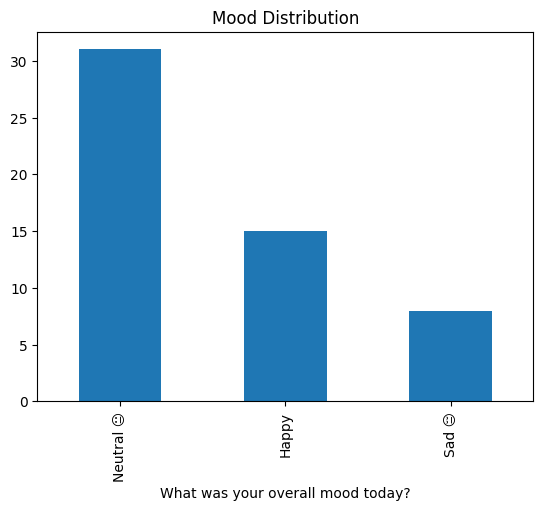

In [ ]:
data["What was your overall mood today?"].value_counts().plot(kind='bar')
plt.title("Mood Distribution")
plt.show()

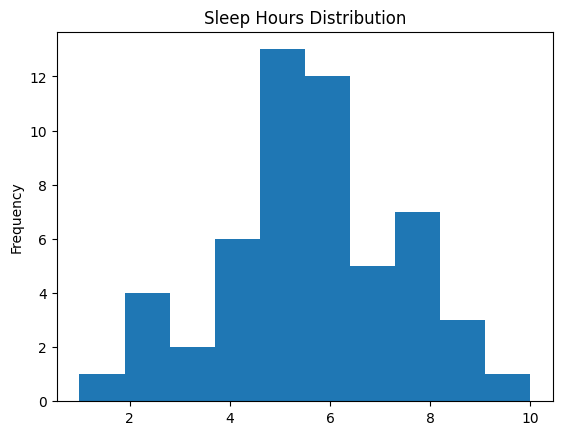

In [ ]:
data["How many hours did you sleep last night?"].plot(kind='hist')
plt.title("Sleep Hours Distribution")
plt.show()

In [ ]:
data["Exercise"] = data["Did you do any physical exercise today?"].map({
    "Yes": 1,
    "No": 0
})

data["Social Interaction"] = data["How was your social interaction today?"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

data["Mood"] = data["What was your overall mood today?"].map({
    "Sad 😔": 0,
    "Neutral 😐": 1,
    "Happy": 2
})

In [ ]:
X = data[
    [
        "How many hours did you sleep last night?",
        "How many hours did you study today?",
        "Exercise",
        "How many hours did you spend on mobile/laptop today?",
        "Social Interaction",
        "What was your stress level today?"
    ]
]
y = data["Mood"]

In [ ]:
print(data.columns)

Index(['Timestamp', 'How many hours did you sleep last night?',
       'How many hours did you study today?',
       'Did you do any physical exercise today?',
       'How many hours did you spend on mobile/laptop today?',
       'How was your social interaction today?',
       'What was your stress level today?',
       'What was your overall mood today?', 'Exercise', 'Social Interaction',
       'Mood'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [ ]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_acc = dt.score(X_test, y_test)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6363636363636364


In [ ]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

lr_acc = lr.score(X_test, y_test)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.5454545454545454


In [ ]:
print("\n===== MODEL COMPARISON =====")
print("Decision Tree:", dt_acc)
print("Logistic Regression:", lr_acc)


===== MODEL COMPARISON =====
Decision Tree: 0.6363636363636364
Logistic Regression: 0.5454545454545454


In [ ]:
if dt_acc > lr_acc:
    print("Best Model: Decision Tree")
else:
    print("Best Model: Logistic Regression")

Best Model: Decision Tree
